In [ ]:
%pip install polars
%pip install numpy
import polars as pl
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!unzip "/content/Financing_to_the_Sustainable_Development_Goals_Dataset_version_1_0.zip" -d "/content/data"

Archive:  /content/Financing_to_the_Sustainable_Development_Goals_Dataset_version_1_0.zip
  inflating: /content/data/Estimating_Baseline_Aid_to_the_Sustainable_Development_Goals.pdf  
   creating: /content/data/__MACOSX/
  inflating: /content/data/__MACOSX/._Estimating_Baseline_Aid_to_the_Sustainable_Development_Goals.pdf  
  inflating: /content/data/FinancingtotheSDGsDataset_v1.0.csv  
  inflating: /content/data/__MACOSX/._FinancingtotheSDGsDataset_v1.0.csv  
  inflating: /content/data/Readme_FinancingtotheSDGsDataset_v1.0.pdf  
  inflating: /content/data/__MACOSX/._Readme_FinancingtotheSDGsDataset_v1.0.pdf  


In [ ]:
data = pl.scan_csv("/content/data/FinancingtotheSDGsDataset_v1.0.csv", infer_schema_length=None)

In [ ]:
from os import mkdir
#mkdir("parquet")
data.explain(optimized=True)
data.sink_parquet('parquet/archivo.parquet')

In [ ]:
data.schema

/tmp/ipykernel_4428/2326241270.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  data.schema


Schema([('aiddata_id', Float64),
        ('year', Int64),
        ('donor', String),
        ('recipient', String),
        ('title', String),
        ('short_description', String),
        ('long_description', String),
        ('aiddata_activity_codes', String),
        ('coalesced_purpose_code', String),
        ('commitment_amount_usd_constant', Float64),
        ('sdg_commitment_amount_usd_constant', String),
        ('goal_1', String),
        ('goal_2', String),
        ('goal_3', String),
        ('goal_4', String),
        ('goal_5', String),
        ('goal_6', String),
        ('goal_7', String),
        ('goal_8', String),
        ('goal_9', String),
        ('goal_10', String),
        ('goal_11', String),
        ('goal_12', String),
        ('goal_13', String),
        ('goal_14', String),
        ('goal_15', String),
        ('goal_16', String),
        ('goal_17', String)])

In [ ]:
df = data.collect()
df.shape

<function tuple.index(value, start=0, stop=9223372036854775807, /)>

In [ ]:
data2 = pl.read_csv("/content/data/FinancingtotheSDGsDataset_v1.0.csv", infer_schema_length=None)

In [ ]:
data2.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [ ]:
data = pl.read_parquet("/content/parquet/archivo.parquet")

In [ ]:
data.head(15)

aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
f64,i64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
9.7800322e7,2010,"""Canada""","""Rwanda""","""Promoting African Grassroots E…","""BUSINESS SUPPORT SERVICES & IN…","""The project aims to improve ac…","""""","""25010""",170872.0,"""170872.03""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""113914.7""","""14239.33""","""0""","""0""","""0""","""0""","""0""","""0""","""28478.67""","""14239.33"""
5.0011571e7,2009,"""France""","""Niger""","""Actions dans le domaine de la …","""ACTIONS DANS LE DOMAINE DE LA …","""Actions dans le domaine de la …","""15140.04""","""15140""",1.526195e6,"""1526195""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""1526195""","""0"""
1.1615453e8,2012,"""Spain""","""Bilateral, unspecified""","""Fourth Preparatory Committee o…","""FOURTH PREPARATORY COMMITTEE O…","""Participación de técnicos del …","""""","""15240""",10594.0,"""10594""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""10594""","""0"""
8.2607504e7,2003,"""United States""","""Morocco""","""ECONOMIC SUPPORT FUND: FY02 CO…","""ECONOMIC SUPPORT FUND""","""OFFICE OF OPERATIONS AND RESOU…","""15150.01|15150.07""","""15150""",770696.0,"""770696""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""770696""","""0"""
9.0600e11,2013,"""France""","""Tunisia""","""Coûts imputés des étudiants ét…","""COÛTS IMPUTÉS DES ÉTUDIANTS ÉT…","""Coûts imputés des étudiants ét…","""11420.06""","""11420""",4.9988696e7,"""49988696""","""0""","""0""","""0""","""49988696""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6.5525835e7,2004,"""Germany""","""Peru""","""INTEGRATED SPECIALIST""","""INTEGRATED SPECIALIST""","""""","""99810.01""","""99810""",88808.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
9.6457779e7,2010,"""United Nations Economic Commis…","""Europe, Regional Programs""","""National Policy Dialogues on I…","""NATIONAL POLICY DIALOGUES ON I…","""""","""14010.02|14040.02""","""14010""",279963.0,"""279963""","""0""","""0""","""0""","""0""","""0""","""139981.5""","""0""","""0""","""69990.75""","""0""","""0""","""0""","""0""","""0""","""0""","""69990.75""","""0"""
1.04927957e8,2011,"""Norway""","""Pakistan""","""mid term review of AKF-Women E…","""MID TERM REVIEW OF AKF-WOMEN E…","""Mid term review of Aga Khan`s …","""""","""15150""",14274.0,"""14274.003""","""0""","""0""","""0""","""0""","""2595.273""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""11678.73""","""0"""


In [ ]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [ ]:
data.null_count()

aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = data.unique()

In [ ]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [ ]:
numeric_df = data.select(pl.selectors.numeric())
display(numeric_df.corr())

aiddata_id,year,commitment_amount_usd_constant
f64,f64,f64
1.0,0.458419,-0.002902
0.458419,1.0,-0.016533
-0.002902,-0.016533,1.0


/tmp/ipykernel_1710/2893741840.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='donor', y='count', palette='viridis')


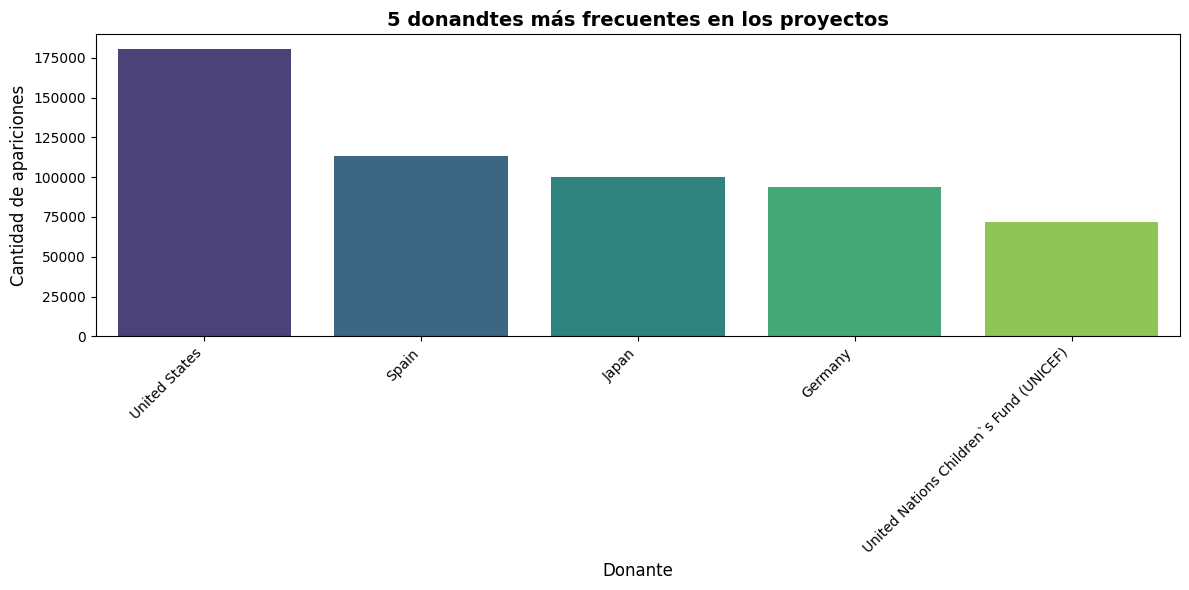

In [ ]:
donor_counts = (
    data["donor"]
    .value_counts(sort=True).head(5)
)


df_counts = donor_counts.to_pandas()


plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='donor', y='count', palette='viridis')
plt.title('5 donandtes más frecuentes en los proyectos', fontsize=14, fontweight='bold')
plt.xlabel('Donante', fontsize=12)
plt.ylabel('Cantidad de apariciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Convertir valores numéricos negativos a 0
import polars.selectors as cs
data = data.with_columns(
    cs.numeric().map_elements(lambda x: max(x, 0), return_dtype=pl.Float64) # O usando clip/when
)

In [ ]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6291e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8099e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",0.0,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""
